In [ ]:
# time period - 1/1/2015 - 1/1/2026
# takes 5 tickers as input (checks in tickers are valid)
# takes risk free rate as input
# max allocation for 1 stock os 40%
# max sector allocation is 60%

Enter EXACTLY 5 stock tickers (comma-separated):  AAPL,GOOGL,SBIN.NS,NVDA,MRF.NS


[*********************100%***********************]  5 of 5 completed

✅ Data fetched successfully.

Selected Stocks: ['AAPL', 'GOOGL', 'SBIN.NS', 'NVDA', 'MRF.NS']


Enter annual risk-free rate (e.g., 0.05 for 5%):  0.05



Sector Mapping:
AAPL: Technology
GOOGL: Communication Services
SBIN.NS: Financial Services
NVDA: Technology
MRF.NS: Consumer Cyclical


[*********************100%***********************]  5 of 5 completed



📊 Optimal Portfolio Allocation:
AAPL: 0.00%
GOOGL: 27.51%
SBIN.NS: 9.13%
NVDA: 40.00%
MRF.NS: 23.36%

📈 Expected Return: 43.22%
📉 Risk (Volatility): 27.05%
⭐ Sharpe Ratio: 1.41


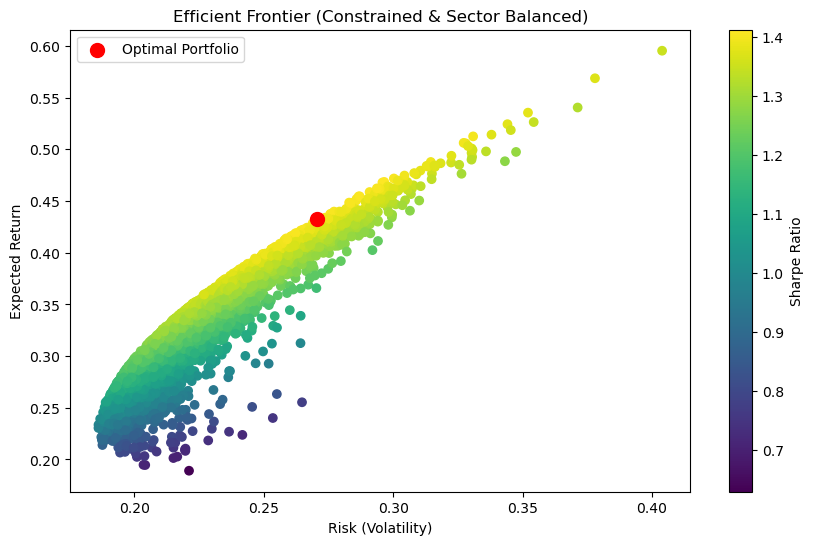

In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 1. User Input with Validation
while True:
    stocks_input = input("Enter EXACTLY 5 stock tickers (comma-separated): ").upper()
    stocks = [s.strip() for s in stocks_input.split(",") if s.strip()]

    if len(stocks) != 5:
        print("❌ Please enter exactly 5 tickers.\n")
        continue

    try:
        test_data = yf.download(stocks, period="5d",auto_adjust= False)['Adj Close']
        if test_data.empty:
            print("❌ Could not fetch data. Try again.\n")
            continue
        print("✅ Data fetched successfully.")
        break
    except:
        print("❌ Error fetching data. Try again.\n")

print("\nSelected Stocks:", stocks)

# 2. Risk-Free Rate Input
while True:
    try:
        risk_free_rate = float(input("Enter annual risk-free rate (e.g., 0.05 for 5%): "))
        break
    except:
        print("❌ Enter a valid number.\n")

# 3. Fetch Sector Data (AUTO)
sector_map = {}

for stock in stocks:
    try:
        ticker = yf.Ticker(stock)
        info = ticker.info
        sector_map[stock] = info.get('sector', 'Other')
    except:
        sector_map[stock] = 'Other'

print("\nSector Mapping:")
for stock in stocks:
    print(f"{stock}: {sector_map[stock]}")

sectors = [sector_map[s] for s in stocks]

# 4. Download Historical Data
data = yf.download(stocks, start='2015-01-01', end='2026-01-01',auto_adjust= False)['Adj Close']

returns = data.pct_change(fill_method=None).dropna()
mean_returns = returns.mean()
cov_matrix = returns.cov()

# 5. Portfolio Performance
def portfolio_performance(weights):
    ret = np.sum(weights * mean_returns) * 252
    std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix * 252, weights)))
    return ret, std

# 6. Sharpe Ratio (with RF)
def negative_sharpe(weights):
    ret, std = portfolio_performance(weights)
    return -(ret - risk_free_rate) / std

# 7. Constraints
num_assets = len(stocks)

constraints = [
    {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}  # weights sum to 1
]

# Sector constraint (max 60%)
unique_sectors = list(set(sectors))

for sector in unique_sectors:
    indices = [i for i, s in enumerate(sectors) if s == sector]
    
    constraints.append({
        'type': 'ineq',
        'fun': lambda x, idx=indices: 0.6 - np.sum(x[idx])
    })

# 8. Bounds (max 40% per stock)
bounds = tuple((0, 0.4) for _ in range(num_assets))

init_guess = num_assets * [1./num_assets]

# 9. Optimization

optimal = minimize(negative_sharpe, init_guess,
                   method='SLSQP',
                   bounds=bounds,
                   constraints=constraints)

weights = optimal.x

# 10. Results
opt_return, opt_std = portfolio_performance(weights)
opt_sharpe = (opt_return - risk_free_rate) / opt_std

print("\n📊 Optimal Portfolio Allocation:")
for stock, w in zip(stocks, weights):
    print(f"{stock}: {w:.2%}")

print(f"\n📈 Expected Return: {opt_return:.2%}")
print(f"📉 Risk (Volatility): {opt_std:.2%}")
print(f"⭐ Sharpe Ratio: {opt_sharpe:.2f}")

# 11. Efficient Frontier
num_portfolios = 5000
results = np.zeros((3, num_portfolios))

for i in range(num_portfolios):
    w = np.random.random(num_assets)
    w /= np.sum(w)

    ret, std = portfolio_performance(w)
    sharpe = (ret - risk_free_rate) / std

    results[0, i] = std
    results[1, i] = ret
    results[2, i] = sharpe

# 12. Plot
plt.figure(figsize=(10,6))
plt.scatter(results[0,:], results[1,:], c=results[2,:], cmap='viridis')
plt.colorbar(label='Sharpe Ratio')

plt.scatter(opt_std, opt_return, color='red', s=100, label='Optimal Portfolio')

plt.xlabel('Risk (Volatility)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier (Constrained & Sector Balanced)')
plt.legend()
plt.show()